In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [4]:
# Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X
y = y.astype(int)

# Normalize X so that pixel values are scaled from [0, 255] to [-1, 1]
X = (X / 255.0) * 2.0 - 1.0

In [5]:
# Split X and y into a temporary set and a test set with 10,000 samples
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)

# Split the temporary set into training and validation sets with 5,000 validation samples
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)

In [6]:
# Implement the sigmoid function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Convert integer labels to one-hot encoded format
def int_to_onehot(y, num_labels):
    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        # set the correct index to 1
        ary[i, val] = 1
    return ary

class NeuralNetMLP:
    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()
        self.num_classes = num_classes
        rng = np.random.RandomState(random_seed)
        # Hidden layer
        self.weight_h = rng.normal(loc=0.0, scale=0.1, size=(num_features, num_hidden))
        self.bias_h = np.zeros(num_hidden)
        # Output layer
        self.weight_out = rng.normal(loc=0.0, scale=0.1, size=(num_hidden, num_classes))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Hidden layer
        z_h = np.dot(x, self.weight_h) + self.bias_h
        a_h = sigmoid(z_h)
        # Output layer
        z_out = np.dot(a_h, self.weight_out) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):
        # One-hot encoding
        y_onehot = int_to_onehot(y, self.num_classes)
        # dLoss/dOutWeights
        d_loss__d_a_out = 2.0 * (a_out - y_onehot) / y.shape[0]
        d_a_out__d_z_out = a_out * (1.0 - a_out)
        delta_out = d_loss__d_a_out * d_a_out__d_z_out
        d_loss__dw_out = np.dot(a_h.T, delta_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        # dLoss/dHiddenWeights
        d_loss__a_h = np.dot(delta_out, self.weight_out.T)
        d_a_h__d_z_h = a_h * (1.0 - a_h)
        delta_h = d_loss__a_h * d_a_h__d_z_h
        d_loss__d_w_h = np.dot(x.T, delta_h)
        d_loss__d_b_h = np.sum(delta_h, axis=0)
        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h, d_loss__d_b_h)

In [7]:
# Create a NeuralNetMLP instance
model = NeuralNetMLP(
    num_features=28*28,
    num_hidden=50,
    num_classes=10
)

# Training parameters
num_epochs = 50
minibatch_size = 100

def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield X[batch_idx], y[batch_idx]

def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)

def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
    for i, (features, targets) in enumerate(minibatch_gen):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        onehot_targets = int_to_onehot(targets, num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        num_examples += targets.shape[0]
        mse += loss
    mse = mse / (i + 1)
    acc = correct_pred / num_examples
    return mse, acc

def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    for e in range(num_epochs):
        minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size)
        for X_train_mini, y_train_mini in minibatch_gen:
            a_h, a_out = model.forward(X_train_mini)
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out

        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')
    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [8]:
print("\nStep 5: Starting model training...")
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model,
    X_train, y_train,
    X_valid, y_valid,
    num_epochs=50,
    learning_rate=0.1
)



Step 5: Starting model training...
Epoch: 001/050 | Train MSE: 0.06 | Train Acc: 74.43% | Valid Acc: 74.48%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 85.59% | Valid Acc: 85.58%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 88.02% | Valid Acc: 88.00%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.30% | Valid Acc: 89.14%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.17% | Valid Acc: 89.88%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.70% | Valid Acc: 90.44%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 91.21% | Valid Acc: 90.94%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.47% | Valid Acc: 91.34%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 91.87% | Valid Acc: 91.62%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.07% | Valid Acc: 92.00%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.41% | Valid Acc: 92.22%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.58% | Valid Acc: 92.38%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.75% | Valid Acc: 92.52%
Epoch: 014/050 

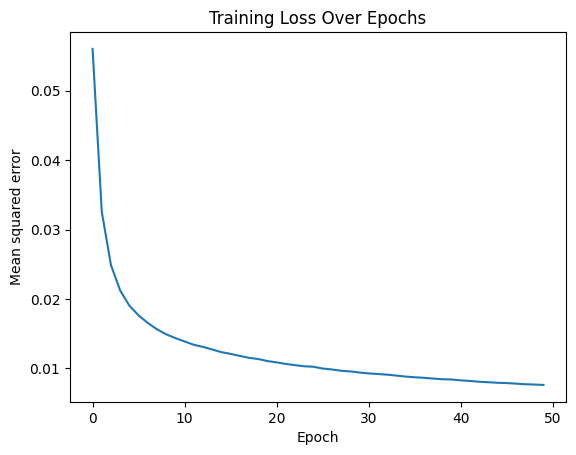

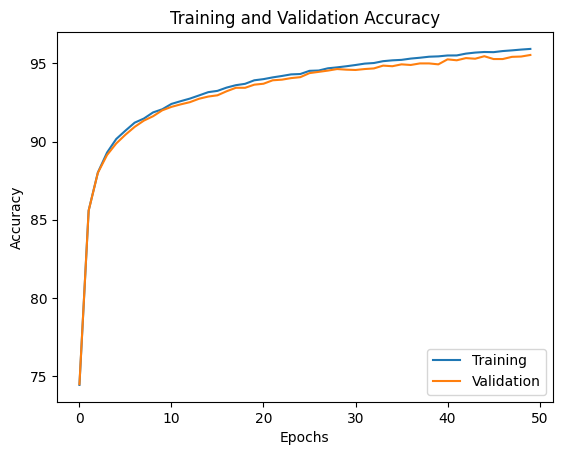


Final Test Accuracy: 95.19%

Displaying misclassified images...


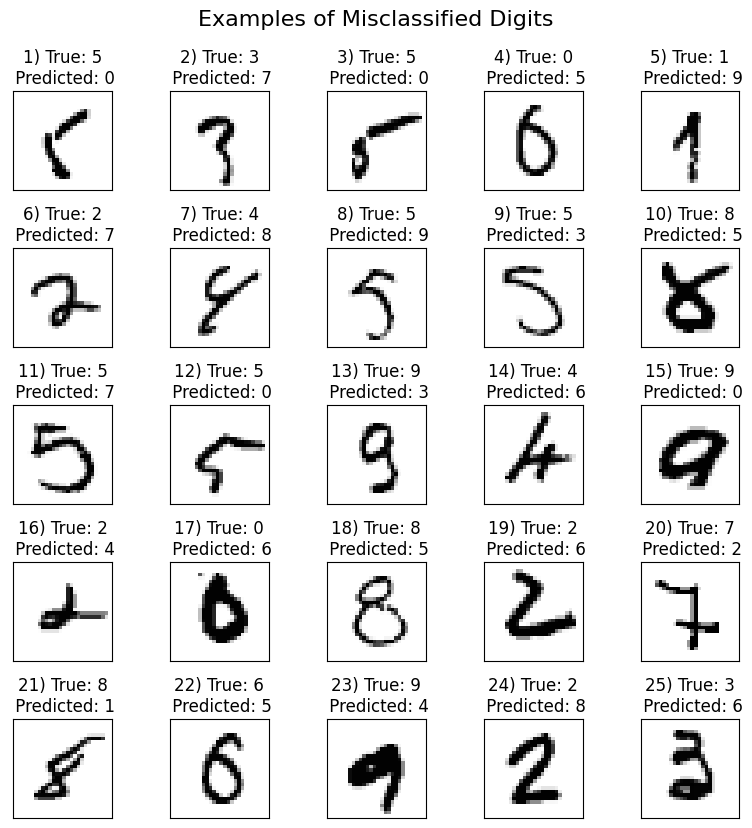

In [9]:
# Plot training loss
plt.figure()
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.title('Training Loss Over Epochs')
plt.show()

# Plot training and validation accuracy
plt.figure()
plt.plot(range(len(epoch_train_acc)), epoch_train_acc, label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Evaluate on the test set
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')

# Visualize misclassified images
print("\nDisplaying misclassified images...")
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]
_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)
misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

fig, ax = plt.subplots(nrows=5, ncols=5,
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.suptitle('Examples of Misclassified Digits', size=16, y=1.03)
plt.show()



### **1. Data Preparation**
First, I loaded the MNIST dataset of handwritten digits. To make it easier for the network to learn, I **normalized** the pixel values from their original `0-255` range to a standard ` -1 to 1` scale. Finally, I split the data into three sets: one for **training** the model, one for **validating** its progress, and a final **test** set for an unbiased evaluation.

### **2. Building the Neural Network**
I then built the neural network model from scratch. This involved setting up the layers and initializing its **weights** (the model's knowledge) with random values. I coded the **forward pass**, which is how the network makes a prediction, and the **backward pass** (backpropagation), which is the crucial step where the model calculates its error and figures out how to adjust its weights to improve.

### **3. Training the Model**
The training process ran for 50 cycles (epochs). In each epoch, I fed the training data to the model in small, random **minibatches** rather than all at once, which is more efficient. For each batch, the model made a prediction, calculated its error, and used backpropagation to slightly adjust its weights to get closer to the correct answer.

### **4. Evaluating the Results**
After training, I evaluated the model's performance. I plotted the accuracy curves to confirm it was learning effectively without just memorizing the data. The final model was then tested on the unseen test set, where it achieved **95.19% accuracy**. I also examined some of the images it got wrong to better understand its limitations